### function

In [18]:
import os
import warnings
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from torch.nn.functional import softmax, cosine_similarity
import logging
import torch
import torch.nn as nn
import numpy as np
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import torch.nn.functional as F
warnings.filterwarnings("ignore")

def setup_device():
    """Set device to GPU if available, otherwise CPU."""  # prefer cuda:1 if exists
    return torch.device('cuda:4' if torch.cuda.is_available() else 'cpu')

def create_similarity_graph(Y, k=15):
    """Create spatial similarity graph using Gaussian kernel on kNN distances."""  # returns (n_spots, n_spots)
    n_spots = Y.shape[0]
    k = min(k, n_spots - 1)
    knn = NearestNeighbors(n_neighbors=k + 1).fit(Y)
    distances, indices = knn.kneighbors(Y)
    S = np.zeros((n_spots, n_spots))
    for i in range(n_spots):
        sigma = max(np.median(distances[i, 1:]), 1e-8)
        for j_idx, j in enumerate(indices[i]):
            if i != j:
                S[i, j] = np.exp(-distances[i, j_idx] ** 2 / (2 * sigma ** 2))
    if np.sum(S) == 0:
        S += np.random.random(S.shape) * 0.01
    return torch.FloatTensor(S)

def find_highly_variable_genes(adata, n_top_genes=1000):
    """Find HVGs using Seurat v3 flavor; fallback to cell_ranger if needed."""  # returns gene indices
    try:
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes)
    except:
        #sc.pp.filter_genes(adata, min_cells=3)
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes)
    return np.where(adata.var['highly_variable'])[0]

def find_common_genes_from_hvg(adata_sc, adata_ST, n_top_genes=1000):
    """Return sorted list of common HVGs between sc and ST data."""  # list of gene names
    adata_sc1=adata_sc.copy()
    adata_ST1=adata_ST.copy()
    sc_genes = set(adata_sc.var_names[find_highly_variable_genes(adata_sc1, n_top_genes)])
    st_genes = set(adata_ST.var_names[find_highly_variable_genes(adata_ST1, n_top_genes)])
    return sorted(sc_genes & st_genes)

def compute_scale_factor(X_sc, X_st):
    """Compute global scale factor = total ST counts / total sc counts."""  # scalar tensor
    return torch.sum(X_st) / torch.sum(X_sc)

def initialize_assignment_matrix(model, X_sc, X_st, n_neighbors=15):
    """Initialize A using kNN in PCA space (soft assignment)."""  # modifies model.A in-place
    device = setup_device()
    X_sc_np = X_sc.cpu().numpy() if torch.is_tensor(X_sc) else X_sc
    X_st_np = X_st.cpu().numpy() if torch.is_tensor(X_st) else X_st
    combined = np.vstack([X_sc_np, X_st_np])
    combined = np.nan_to_num(combined, nan=0.0)
    row_sums = combined.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1.0, row_sums)
    normalized = combined / row_sums * row_sums.mean()
    pca = PCA(n_components=min(50, normalized.shape[1]))
    sc_pca = pca.fit_transform(normalized)[:X_sc_np.shape[0]]
    st_pca = pca.transform(normalized)[X_sc_np.shape[0]:]
    knn = NearestNeighbors(n_neighbors=min(n_neighbors, sc_pca.shape[0] - 1)).fit(sc_pca)
    _, indices = knn.kneighbors(st_pca)
    A_init = torch.zeros(model.n_st_spots, model.n_sc_cells)
    A_init = np.log(1e-10)*A_init
    for i in range(model.n_st_spots):
        A_init[i, indices[i]] = np.log(1.0 / len(indices[i]))  # uniform init over neighbors
    A_init=torch.tensor(np.random.normal(0,1,(model.n_st_spots, model.n_sc_cells)),dtype=torch.float32)
    model.A.data = A_init.to(device)
    return sc_pca

def load_and_align_data(sc_path, st_path, n_top_genes=1000,common_genes=None,fix_genes=False):
    """Load, filter, and align sc/ST data on common HVGs."""  # returns tensors + metadata
    """Load, filter, and align sc/ST data on common HVGs."""  # returns tensors + metadata
    adata_ST = sc.read(st_path)
    adata_sc = sc.read(sc_path)
    sc.pp.normalize_total(adata_sc) 
    #sc.pp.filter_genes(adata_sc, min_cells=3); sc.pp.filter_cells(adata_sc, min_genes=200)
    #sc.pp.filter_genes(adata_ST, min_cells=3); sc.pp.filter_cells(adata_ST, min_genes=200)
    if common_genes is None:
        common_genes = find_common_genes_from_hvg(adata_sc, adata_ST, n_top_genes)
    print('the number of common gene are',len(common_genes))
    assert len(common_genes) >= 100, "Too few common HVGs (<100)"
    if fix_genes==False:
        common_genes=list(set(common_genes)&set(adata_ST.var_names))
        common_genes=list(set(common_genes)&set(adata_sc.var_names))
    X_sc = adata_sc[:, common_genes].X.toarray() if hasattr(adata_sc.X, 'toarray') else adata_sc[:, common_genes].X
    X_st = adata_ST[:, common_genes].X.toarray() if hasattr(adata_ST.X, 'toarray') else adata_ST[:, common_genes].X
    X_sc, X_st = torch.FloatTensor(X_sc), torch.FloatTensor(X_st)
    Y = torch.FloatTensor(adata_ST.obsm['spatial']) if 'spatial' in adata_ST.obsm else None
    return X_sc, X_st, Y, adata_sc, adata_ST, common_genes



class VAEImprovedSpatialModel(nn.Module):
    def __init__(self, n_sc_cells, n_st_spots, n_genes, embedding_dim=8,
                 lambda_reg=0, lambda_l2=1,lambda_l4=0,lambda_l5=0, lambda_ot=-1, lambda_M=1, lambda_M1=1,lambda_r=0, lambda_kl=0.1,lambda_pca=1,lambda_f=0, lambda_row_sum=1.0,predictA=None):
        super().__init__()
        self.n_sc_cells = n_sc_cells
        self.n_st_spots = n_st_spots
        self.n_genes = n_genes
        self.embedding_dim = embedding_dim
        self.lambda_reg = lambda_reg
        self.lambda_l2 = lambda_l2
        self.lambda_l4 = lambda_l4
        self.lambda_l5 = lambda_l5
        self.lambda_ot = lambda_ot
        self.lambda_r = lambda_r
        self.lambda_M = lambda_M
        self.lambda_M1 = lambda_M1
        self.lambda_kl = lambda_kl  # 新增 KL 权重
        self.lambda_pca = lambda_pca
        self.lambda_f = lambda_f
        self.lambda_row_sum = lambda_row_sum
        self._density_criterion = torch.nn.KLDivLoss(reduction="mean")
        # --- Gene embedding (still learnable) ---
        # --- Encoder for single-cell counts (VAE style) ---
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64), nn.ReLU()
        )
        self.predictA=predictA
        self.fc_mu = nn.Linear(64, embedding_dim)
        self.fc_logvar = nn.Linear(64, embedding_dim)
        # --- Decoder: reconstruct expression from z_cell and z_gene ---
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, n_genes),
            nn.Softplus()  # ensures λ > 0 for Poisson
        )
        self.align_mlp = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim), nn.ReLU(),
            nn.Linear(embedding_dim, embedding_dim)
        )
        # --- Assignment matrix A ---
        device = setup_device()
        #self.A = nn.Parameter(torch.randn(n_st_spots, n_sc_cells, device=device) * 0.01)
        self.A = np.random.normal(0, 1, (n_st_spots, n_sc_cells))
        self.A = nn.Parameter(torch.tensor(self.A, device=device, requires_grad=True, dtype=torch.float32))
        self.f = nn.Parameter(torch.randn( n_sc_cells,1, device=device) )
        self.log_scale = nn.Parameter(torch.tensor(0.0))  # for ST scaling

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode_sc(self, X_sc):
        # X_sc: (n_cells, n_genes), raw counts (non-negative)
        h = self.encoder(X_sc)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10, max=10)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def decode_expression(self, z_cell):
        out = self.decoder(z_cell)    # (n*g, 1)
        return out                   # (n, g)

    def kl_loss(self, mu, logvar):
        return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    def row_sum_mse_loss(self, num_cell):
        A_hat = self.compute_softmax_A()
        row_sums = A_hat.sum(dim=1)
        num_cell = num_cell.view(-1)
        if row_sums.shape != num_cell.shape:
            num_cell = num_cell.expand_as(row_sums)
        return F.mse_loss(row_sums, num_cell)

    def compute_softmax_A(self):
        return F.softmax(self.A, dim=0)

    def compute_st_embedding(self, z_cell):
        A_hat = self.compute_softmax_A()
        return torch.mm(A_hat, z_cell)

    def poisson_nll_loss(self, y_true, lam):
        lam = torch.clamp(lam, min=1e-8)
        # y_true: non-negative integers, lam: positive reals
        return F.poisson_nll_loss(
            input=torch.log(lam + 1e-8),
            target=y_true,
            log_input=True,
            full=False,
            reduction='mean'
        )

    def loss_L1(self, X_sc, f_vals):
        return self.poisson_nll_loss(X_sc, f_vals)

    def loss_L1_cos(self, X_sc, f_vals):
        gv = 1 - 0.5 * cosine_similarity(f_vals, X_sc, dim=0).mean()
        #vg = 1 - 0.5 * cosine_similarity(f_vals, X_sc, dim=1).mean()
        return gv #+ vg
    def loss_L2(self, X_st, f_vals,A_softmax=None):
        if self.lambda_f==0:
            X_st_pred = torch.mm(A_softmax, f_vals) 
        else:
            f_sigmoid = torch.sigmoid(self.f)
            s_vec = f_sigmoid.squeeze()  
            if f_vals.dim() == 1:
                weighted_vec = s_vec * f_vals       # Shape: [152687]
            else:
                weighted_vec = s_vec.unsqueeze(-1) * f_vals # Shape: [152687, D]
            if weighted_vec.dim() == 1:
                X_st_pred = torch.mm(A_softmax, weighted_vec) 
            else:
                X_st_pred = torch.mm(A_softmax, weighted_vec)
        return self.poisson_nll_loss(X_st, self.log_scale * X_st_pred)

    def loss_L3(self, z_st, S):
        diff = z_st.unsqueeze(1) - z_st.unsqueeze(0)
        sq_diff = torch.mean(diff ** 2, dim=2)
        return torch.mean(S * sq_diff) if torch.sum(S) > 0 else torch.sum(sq_diff) * 1e-6
    def loss_LM(self, X_sc, X_st):
        A_softmax = self.compute_softmax_A()
        if self.lambda_f==0:
            G_pred = torch.matmul(A_softmax, X_sc)
        else:
            f_sigmoid = torch.sigmoid(self.f)
            weighted_X_sc = f_sigmoid * X_sc 
            G_pred = torch.matmul(A_softmax, weighted_X_sc)
        #G_pred = torch.matmul(M_probs,torch.diag(f_sigmoid.squeeze())@ X_sc)
        gv = 1 - 0.5 * cosine_similarity(G_pred, X_st, dim=0).mean()
        vg = 1 - 0.5 * cosine_similarity(G_pred, X_st, dim=1).mean()
        return gv #+ vg
    def custom_loss(self):
        f_sigmoid = torch.sigmoid(self.f)
        return torch.mean(f_sigmoid - f_sigmoid**2)
    
    def row_sum_mse_loss(self, num_cell):
        A_softmax = self.compute_softmax_A()
        
        if self.lambda_f==0:
            A = A_softmax
        else:    
            sigmoid_f = torch.sigmoid(self.f).squeeze()
            A = A_softmax  * sigmoid_f 
        row_sums = A.sum(dim=1)/A.sum()
        row_sums=torch.log(row_sums)
        num_cell=num_cell/num_cell.sum()
        #similarity = F.cosine_similarity(row_sums.unsqueeze(0), num_cell.unsqueeze(0), dim=1).mean()
        #return F.mse_loss(row_sums, num_cell, reduction='mean')
        density_term=self._density_criterion(row_sums.unsqueeze(0), num_cell.unsqueeze(0))
        return density_term    

    def forward(self, X_sc, X_st, z_pca=None, S=None, num_cell=None,f_vals=None,z_cell=None):
        target_dtype = next(self.parameters()).dtype

        def ensure_dtype(tensor):
            if tensor is None:
                return None
            if tensor.dtype != target_dtype:
                return tensor.to(target_dtype)
            return tensor

        X_sc = ensure_dtype(X_sc)
        X_st = ensure_dtype(X_st)
        if self.predictA is not None:
            S = ensure_dtype(S) 
            num_cell = ensure_dtype(num_cell)
            z_st = self.compute_st_embedding(z_cell)
            l3 = self.loss_L3(z_st, S)
            LM = self.loss_LM(X_sc, X_st) 
            LM1 = self.loss_LM(f_vals, X_st)
            l_f=self.custom_loss()
            if num_cell is not None:
                row_sum_loss = self.row_sum_mse_loss(num_cell)
            total = (self.lambda_M * LM +self.lambda_M1 * LM1 +self.lambda_f *l_f+self.lambda_row_sum * row_sum_loss+self.lambda_reg * l3 )
            return total, LM, LM1, l_f, row_sum_loss, l3
        else:
            z_cell, mu, logvar = self.encode_sc(X_sc)  # important: float!
            f_vals = self.decode_expression(z_cell)
            l1 = self.loss_L1(X_sc, f_vals)
            kl = self.kl_loss(mu, logvar)
            l4 = self.loss_L1_cos(X_sc, f_vals)
            if z_pca is None:
                raise ValueError("z_pca must be provided for alignment loss.")
            z_cell_proj = self.align_mlp(z_cell)
            z_pca = torch.tensor(z_pca, device=X_sc.device, dtype=X_sc.dtype)
            loss_align = F.mse_loss(z_cell_proj, z_pca, reduction='mean')
            total = (l1 + self.lambda_pca * loss_align + self.lambda_kl * kl + self.lambda_l4 * l4)
            return total, l1, l4, kl, loss_align


        



def train_vae_poisson_model(sc_path, st_path, C=None, num_cell=None, output_dir='SpatialVG_VAE_Poisson', common_genes=None,
                            embedding_dim=8, lr=0.01, epochs=300,
                            lambda_reg=0.5, lambda_l2=1, lambda_l4=1, lambda_l5=1, lambda_ot=-1,
                            lambda_M=1, lambda_M1=1, lambda_r=-10000, lambda_kl=0.1, lambda_pca=1, lambda_f=1, lambda_row_sum=1.0,
                            n_top_genes=1000, z_pca=None, predictA=None,f_vals=None,z_cell=None, fix_genes=False):
    device = setup_device()
    os.makedirs(f'{output_dir}/models', exist_ok=True)
    os.makedirs(f'{output_dir}/evaluation', exist_ok=True)

    X_sc, X_st, Y, adata_sc, adata_ST, genes = load_and_align_data(sc_path, st_path, n_top_genes=n_top_genes, common_genes=common_genes, fix_genes=fix_genes)
    X_sc = np.log(X_sc + 1)
    X_st = np.log(X_st + 1)
    if predictA is not None:
        S = create_similarity_graph(Y.numpy()) if Y is not None else torch.zeros(X_st.shape[0], X_st.shape[0])
        S = S.to(device)
    X_sc, X_st= X_sc.to(device), X_st.to(device)

    model = VAEImprovedSpatialModel(
        n_sc_cells=X_sc.shape[0],
        n_st_spots=X_st.shape[0],
        n_genes=X_sc.shape[1],
        embedding_dim=embedding_dim,
        lambda_reg=lambda_reg,
        lambda_l2=lambda_l2,
        lambda_l4=lambda_l4,
        lambda_l5=lambda_l5,
        lambda_ot=lambda_ot,
        lambda_M=lambda_M,
        lambda_M1=lambda_M1,
        lambda_r=lambda_r,
        lambda_kl=lambda_kl,
        lambda_pca=lambda_pca,
        lambda_f=lambda_f,
        lambda_row_sum=lambda_row_sum,
        predictA=predictA
    ).to(device)
    if z_pca is None:
        pca_sc = initialize_assignment_matrix(model, X_sc, X_st, n_neighbors=15)
    else:
        pca_sc = z_pca.copy()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.8)

    best_loss, patience = float('inf'), 0
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        if predictA is None:
            total, l1, l2,kl, loss_align = model(X_sc, X_st,z_pca=  pca_sc[:, :embedding_dim])
        else:
            total, LM, LM1, l_f, row_sum_loss, l3 = model(X_sc, X_st,S=S, num_cell=num_cell,f_vals=f_vals,z_cell=z_cell)
        if torch.isnan(total).any():
            print(f"NaN detected at epoch {epoch}. Stopping training.")
            break
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        if predictA is None:
            losses.append({
            'epoch': epoch,
            'total': total.item(),
            'l1': l1.item(),
            'kl': kl.item(),
            'loss_align': loss_align.item()
            })
        else:
            losses.append({
            'epoch': epoch,
            'total': total.item(),
            'LM': LM.item(),
            'LM1': LM1.item(),
            'l_f': l_f.item(),
            'row_sum_loss': row_sum_loss.item(),
            'l3': l3.item()
            })

        if total.item() < best_loss:
            best_loss, patience = total.item(), 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'common_genes': genes,
                'config': {
                    'n_sc_cells': X_sc.shape[0],
                    'n_st_spots': X_st.shape[0],
                    'n_genes': X_sc.shape[1],
                    'embedding_dim': embedding_dim,
                    'lambda_reg': lambda_reg,
                    'lambda_l2': lambda_l2,
                    'lambda_l4': lambda_l4,
                    'lambda_l5': lambda_l5,
                    'lambda_ot': lambda_ot,
                    'lambda_M': lambda_M,
                    'lambda_r': lambda_r,
                    'lambda_kl': lambda_kl,
                    'loss_align': lambda_pca,
                    'loss_f': lambda_f,
                    'lambda_row_sum': lambda_row_sum
                }
            }, f'{output_dir}/models/best_vae_poisson_model.pth')
        else:
            patience += 1
            if patience >= 200:
                break

        if epoch % 20 == 0:
            if predictA is None:
                print(f'Epoch {epoch:3d}: Total={total:.2f}, L1={l1:.2f},L4={l2:.2f}, KL={kl:.2f}, PCA={loss_align:.2f}')
            else:
                print(f'Epoch {epoch:3d}: Total={total:.2f}, LM={LM:.2f},LM1={LM1:.2f}, l_f={l_f:.2f}, row_sum_loss={10000*row_sum_loss:.2f},l3={l3:.2f}')
    return model, genes, losses


In [19]:
import numpy as np
import pandas as pd
#spot_to_cells=adata_st.uns["spot_to_cells"]
def build_A_gt_from_spot_to_cells(adata_st, adata_sc, spot_to_cells):
    """
    Build ground truth assignment matrix A_gt (n_spots x n_cells).
    Args:
        adata_st: AnnData with obs_names like ['Spot_0', 'Spot_1', ...]
        adata_sc: AnnData with obs_names like ['Cell_0', 'Cell_1', ...]
        spot_to_cells: dict, e.g., {"Spot_0": [10, 25], "Spot_1": [88], ...}
    Returns:
        A_gt: np.ndarray of shape (n_spots, n_cells), dtype=float32
    """
    n_spots = adata_st.n_obs
    n_cells = adata_sc.n_obs
    A_gt = np.zeros((n_spots, n_cells), dtype=np.float16)

    # Ensure adata_st.obs_names matches the keys in spot_to_cells
    for i, spot_name in enumerate(adata_st.obs_names):
        if spot_name in spot_to_cells:
            cell_indices = spot_to_cells[spot_name]
            for cid in cell_indices:
                if 0 <= cid < n_cells:
                    A_gt[i, cid] = 1.0
                else:
                    raise ValueError(f"Cell index {cid} out of range for {n_cells} cells")
        # else: no cells assigned → all zeros (already initialized)
    return A_gt
import numpy as np
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
# 假设 scembedding 是 (n_cells, n_features) 的 numpy array
# y 是长度为 n_cells 的标签数组（cluster labels）
# 方法 1：使用 scipy 的 pdist with 'correlation' (推荐)
from scipy.spatial.distance import pdist, squareform
def evaluate_predictions_numpy(
    predictsc,              # (n_sc_cells, n_genes) or embedding
    scembeding,
    X_sc_true,              # same shape as predictsc (optional, can be None)
    predictst=None,         # (n_spots, n_genes)
    X_st_true=None,         # (n_spots, n_genes)
    predictA=None,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=None,  # list[str], length = n_sc_cells
    A_gt_deconv=None,       # (n_spots, n_types)
    cell_types_gt_order=None
):
    """
    Pure numpy evaluation.
    Some inputs can be None.
    """

    metrics = {}

    # Ensure numpy
    if predictsc is not None:
        predictsc = np.asarray(predictsc, dtype=np.float32)
    if X_sc_true is not None:
        X_sc_true = np.asarray(X_sc_true, dtype=np.float32)
    if predictst is not None:
        predictst = np.asarray(predictst, dtype=np.float32)
    if X_st_true is not None:
        X_st_true = np.asarray(X_st_true, dtype=np.float32)
    if predictA is not None:
        predictA = np.asarray(predictA, dtype=np.float32)
    if A_gt is not None:
        A_gt = np.asarray(A_gt, dtype=np.float32)

    # -------------------------------
    # 1️⃣ Expression PCC
    # -------------------------------
    def mean_pcc(x_true, x_pred):
        row_pccs, col_pccs = [], []
        for i in range(x_true.shape[0]):
            t, p = x_true[i], x_pred[i]
            if np.std(t) > 1e-8 and np.std(p) > 1e-8:
                r, _ = pearsonr(t, p)
                row_pccs.append(float(r))
            else:
                row_pccs.append(0.0)
        for j in range(x_true.shape[1]):
            t, p = x_true[:, j], x_pred[:, j]
            if np.std(t) > 1e-8 and np.std(p) > 1e-8:
                r, _ = pearsonr(t, p)
                col_pccs.append(float(r))
            else:
                col_pccs.append(0.0)
        return np.mean(row_pccs), np.mean(col_pccs)

    if predictsc is not None and X_sc_true is not None:
        f_row_pcc, f_col_pcc = mean_pcc(X_sc_true, predictsc)
        metrics['predictsc_row_pcc'] = float(f_row_pcc)
        metrics['predictsc_col_pcc'] = float(f_col_pcc)

    if predictst is not None and X_st_true is not None:
        st_row_pcc, st_col_pcc = mean_pcc(X_st_true, predictst)
        metrics['predictst_row_pcc'] = float(st_row_pcc)
        metrics['predictst_col_pcc'] = float(st_col_pcc)

    # -------------------------------
    # 2️⃣ Assignment Accuracy
    # -------------------------------
    if predictA is not None and A_gt is not None:
        pred_assign = np.argmax(predictA, axis=1)
        true_assign = np.argmax(A_gt, axis=1)
        metrics['assignment_accuracy'] = float(np.mean(pred_assign == true_assign))

    # -------------------------------
    # 3️⃣ Deconvolution
    # -------------------------------
    dec_pred_aligned = None

    if predictA is not None and cell_type_labels is not None:
        le = LabelEncoder()
        labels = le.fit_transform(cell_type_labels)
        n_types = len(le.classes_)
        one_hot_sc = np.eye(n_types)[labels]
        dec_pred_raw = predictA @ one_hot_sc  # (n_spots, n_types)
        dec_pred_raw = dec_pred_raw / (dec_pred_raw.sum(axis=1, keepdims=True) )  # row-normalize
        if A_gt_deconv is not None:
            A_gt_deconv = np.asarray(A_gt_deconv, dtype=np.float32)
            pred_order = le.classes_.tolist()
            gt_order = cell_types_gt_order
            reorder_idx = [pred_order.index(ct) for ct in gt_order]
            dec_pred_aligned = dec_pred_raw[:, reorder_idx]
            # Row-wise PCC
            pcc_list = []
            for i in range(A_gt_deconv.shape[0]):
                gt_i = A_gt_deconv[i]
                pred_i = dec_pred_aligned[i]
                if np.std(gt_i) < 1e-8 or np.std(pred_i) < 1e-8:
                    r = 0.0
                else:
                    r, _ = pearsonr(gt_i, pred_i)
                    r = float(r) if np.isfinite(r) else 0.0
                pcc_list.append(r)
            metrics['deconv_mean_pcc'] = float(np.mean(pcc_list))
            metrics['deconv_mean_mae'] = float(np.mean(np.abs(A_gt_deconv - dec_pred_aligned)))
            metrics['deconv_mean_rmse'] = float(np.sqrt(np.mean((A_gt_deconv - dec_pred_aligned) ** 2)))
            metrics['PCC_all']=pcc_list

    # -------------------------------
    # 4️⃣ Silhouette Index (NEW)
    # -------------------------------
    if scembeding is not None and cell_type_labels is not None:
        le = LabelEncoder()
        y = le.fit_transform(cell_type_labels)
        if len(np.unique(y)) > 1:
            correlation_distances = pdist(scembeding, metric='correlation')  # shape: (n*(n-1)/2,)
            distance_matrix = squareform(correlation_distances)  # shape: (n, n)
            sil = silhouette_score(distance_matrix, y, metric='precomputed')
            # sil= silhouette_score(scembeding, y, metric='euclidean')
            metrics['silhouette_index'] = float(sil)
        else:
            metrics['silhouette_index'] = 0.0

    print("✅ Evaluation complete.")
    # -------------------------------
    # 5️⃣ Visualization: per-cell-type gene scatter (NEW)
    # -------------------------------
    if predictsc is not None and X_sc_true is not None and cell_type_labels is not None:
        import matplotlib.pyplot as plt

        predictsc = np.asarray(predictsc)
        X_sc_true = np.asarray(X_sc_true)

        cell_type_labels = np.asarray(cell_type_labels)
        unique_types = np.unique(cell_type_labels)

        # 固定最多画 10 个 cell type
        unique_types = unique_types[:10]
        n_types = len(unique_types)

        n_cols = 5
        n_rows = int(np.ceil(n_types / n_cols))

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(4 * n_cols, 4 * n_rows),
            squeeze=False
        )

        for idx, ct in enumerate(unique_types):
            row = idx // n_cols
            col = idx % n_cols
            ax = axes[row, col]

            # 找到该 cell type 的所有 cell
            ct_indices = np.where(cell_type_labels == ct)[0]
            if len(ct_indices) == 0:
                ax.axis("off")
                continue

            # 抽一个 cell（固定第一个，保证可复现；也可以改成 np.random.choice）
            cell_idx = ct_indices[0]

            x = X_sc_true[cell_idx]
            y = predictsc[cell_idx]

            # 计算 PCC
            if np.std(x) > 1e-8 and np.std(y) > 1e-8:
                r, _ = pearsonr(x, y)
            else:
                r = 0.0

            ax.scatter(x, y, s=6, alpha=0.6)
            ax.set_title(f"{ct}\nPCC={r:.2f}", fontsize=10)
            ax.set_xlabel("X_sc_true")
            ax.set_ylabel("predictsc")

        # 关掉多余子图
        for j in range(idx + 1, n_rows * n_cols):
            axes[j // n_cols, j % n_cols].axis("off")

        plt.tight_layout()
        plt.show()
    return metrics,dec_pred_aligned

In [20]:
##### by zzzz
pcaguide=pd.read_csv('harmony_embedding.txt', sep='\t', index_col=0)
genelist=pd.read_csv('/home/qyyuan/project/ST_CP/JE/compare/spotiphy/Spotiphy_Result/marker_gene.csv',sep=',',index_col=0)
common_genes=genelist['gene'].values
markers =  np.load('/home/qyyuan/project/ST_CP/JE/Tangram/20k_markers.npy')
common_genes=markers.tolist()
sc_data_path = "/home/qyyuan/project/ST_CP/JE/method/data/scRNA_subsampled_20k.h5ad"
st_data_path = "/home/qyyuan/project/ST_CP/JE/compare/groundtruth/NM_yangjy_X/data/Visium_FAD.h5ad"
count_file_path='/home/qyyuan/project/ST_CP/JE/method/stardist/count_spot/spot_loc_with_counts_r_f.csv'
C = np.load("data/C_matrix_subsampled_20k.npy")
C = torch.tensor(C,device='cuda:2',dtype=torch.float32)
Count_cell=pd.read_csv(count_file_path)
num_cell=Count_cell['n_cells'].values
num_cell = torch.tensor(num_cell, device='cuda:2')
import os
import torch
import numpy as np66

print("=" * 60)
print("Starting improved model training")
print("=" * 60)
# Train model
model, common_genes, losses = train_vae_poisson_model(
    sc_path=sc_data_path,
    st_path=st_data_path,
    C=C, 
    num_cell=num_cell,
    output_dir='SpatialVG_improved_NMF', common_genes=common_genes,
    embedding_dim=32, 
    lr=0.05, 
    epochs=500, 
    lambda_reg=0,lambda_l2=0,lambda_l4=2,lambda_l5=0.0000000,lambda_ot=0, lambda_M=0,lambda_M1=0,lambda_r=0.0000,lambda_kl=0.0001,lambda_pca=1,lambda_f=0,lambda_row_sum=0,
    n_top_genes=5000 ,
    z_pca=pcaguide.values
)
# Save results
os.makedirs('SpatialVG_improved_NMF-train-test/models', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'common_genes': common_genes,
    'training_losses': losses,
}, 'SpatialVG_improved_NMF/models/fix_enc_pca1_top5000_kl_soft_harm-best_result0.5-withmarker2.pth')
print("Training completed and model saved.")

Starting improved model training
the number of common gene are 1605
Epoch   0: Total=21.88, L1=0.90,L4=0.76, KL=0.13, PCA=19.46
Epoch  20: Total=8.52, L1=0.46,L4=0.64, KL=10.44, PCA=6.77
Epoch  40: Total=6.53, L1=0.44,L4=0.63, KL=15.12, PCA=4.84
Epoch  60: Total=5.20, L1=0.43,L4=0.62, KL=15.75, PCA=3.53
Epoch  80: Total=4.34, L1=0.43,L4=0.61, KL=15.12, PCA=2.68
Epoch 100: Total=3.73, L1=0.42,L4=0.61, KL=15.01, PCA=2.08
Epoch 120: Total=3.37, L1=0.42,L4=0.61, KL=14.82, PCA=1.73
Epoch 140: Total=3.16, L1=0.42,L4=0.61, KL=14.57, PCA=1.52
Epoch 160: Total=2.93, L1=0.42,L4=0.61, KL=14.00, PCA=1.30
Epoch 180: Total=2.75, L1=0.42,L4=0.60, KL=13.58, PCA=1.13
Epoch 200: Total=2.64, L1=0.42,L4=0.60, KL=13.61, PCA=1.02
Epoch 220: Total=2.58, L1=0.42,L4=0.60, KL=13.29, PCA=0.96
Epoch 240: Total=2.53, L1=0.42,L4=0.60, KL=12.98, PCA=0.91
Epoch 260: Total=2.47, L1=0.42,L4=0.60, KL=12.76, PCA=0.85
Epoch 280: Total=2.43, L1=0.41,L4=0.60, KL=12.51, PCA=0.81
Epoch 300: Total=2.39, L1=0.41,L4=0.60, KL=12.

### performance

In [21]:
sc_path = "/home/qyyuan/project/ST_CP/JE/method/data/scRNA_subsampled_20k.h5ad"
st_path = "/home/qyyuan/project/ST_CP/JE/compare/groundtruth/NM_yangjy_X/data/Visium_FAD.h5ad"
# 1. 定义设备
n_top_genes=5000
genelist=pd.read_csv('/home/qyyuan/project/ST_CP/JE/compare/spotiphy/Spotiphy_Result/marker_gene.csv',sep=',',index_col=0)
common_genes=genelist['gene'].values
markers =  np.load('/home/qyyuan/project/ST_CP/JE/Tangram/20k_markers.npy')
common_genes=markers.tolist()
device = torch.device('cuda:4' if torch.cuda.is_available() else 'cpu')
X_sc, X_st, Y, adata_sc, adata_ST, common_genes = load_and_align_data(sc_path, st_path, n_top_genes,common_genes=common_genes)
X_sc = np.log(X_sc + 1)
X_st = np.log(X_st + 1)
checkpoint_path = 'SpatialVG_improved_NMF/models/fix_enc_pca1_top5000_kl_soft_harm-best_result0.5-withmarker2.pth'
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
common_genes=checkpoint['common_genes']
n_sc_cells=X_sc.shape[0]
n_st_spots=X_st.shape[0]
n_genes=len(common_genes)
embedding_dim = 64    # 你训练时用的是 16
adata_sc=adata_sc[:,common_genes]
adata_st=adata_ST[:,common_genes]
import pandas as pd
A_gt_deconv=pd.read_csv('/home/qyyuan/project/ST_CP/JE/compare/groundtruth/NM_yangjy_X/data/S3_GT.txt',sep='\t',header=0,index_col=0)

the number of common gene are 1605


In [22]:
model.eval()
device = next(model.parameters()).device
# 假设 X_sc 已经在函数作用域内（或作为参数传入）
# 确保 X_sc 是 float tensor 并在正确设备上
import torch
# 2. 再转为 float 并移动到 device
X_sc_tensor = X_sc.to(device).float()
with torch.no_grad():
    # Encode single-cell data to get z_cell (this replaces old model.z_sc)
    z_cell, _, _ = model.encode_sc(X_sc_tensor)  # shape: (n_cells, embedding_dim)
    f_vals = model.decoder(z_cell)
    # Compute spatial prediction
    A_hat = model.compute_softmax_A()
    scale = torch.exp(model.log_scale)
    #A_hat = A_hat #* sigmoid_f.T
    X_st_pred = torch.mm(scale * A_hat, f_vals)
    sigmoid_f = torch.sigmoid(model.f)
# Convert to numpy
predictsc = f_vals.cpu().numpy()
X_st_pred = X_st_pred.cpu().numpy()
A_hat_np = A_hat.cpu().numpy()
scembeding = z_cell.cpu().numpy()  # this is your new latent representation
metadata = adata_sc.obs.copy()
cell_type_labels =metadata['cell_type'].values
cell_types_gt_order=A_gt_deconv.columns.tolist()
A_hat_np=pd.DataFrame(A_hat_np,index=adata_st.obs_names,columns=adata_sc.obs_names)
A_hat_np=A_hat_np.loc[A_gt_deconv.index,:]
cell_types_gt_order=A_gt_deconv.columns.tolist()
A_hat_np=pd.DataFrame(A_hat_np,index=adata_st.obs_names,columns=adata_sc.obs_names)
A_hat_np=A_hat_np.loc[A_gt_deconv.index,:]

In [23]:
np.save('fix_enc_pca1_top5000_kl_soft_harm_fval-tangram_jiyuanyang.npy', predictsc)
np.save('fix_enc_pca1_top5000_kl_soft_harm_z_cell-tangram_jiyuanyang.npy', scembeding)

✅ Evaluation complete.


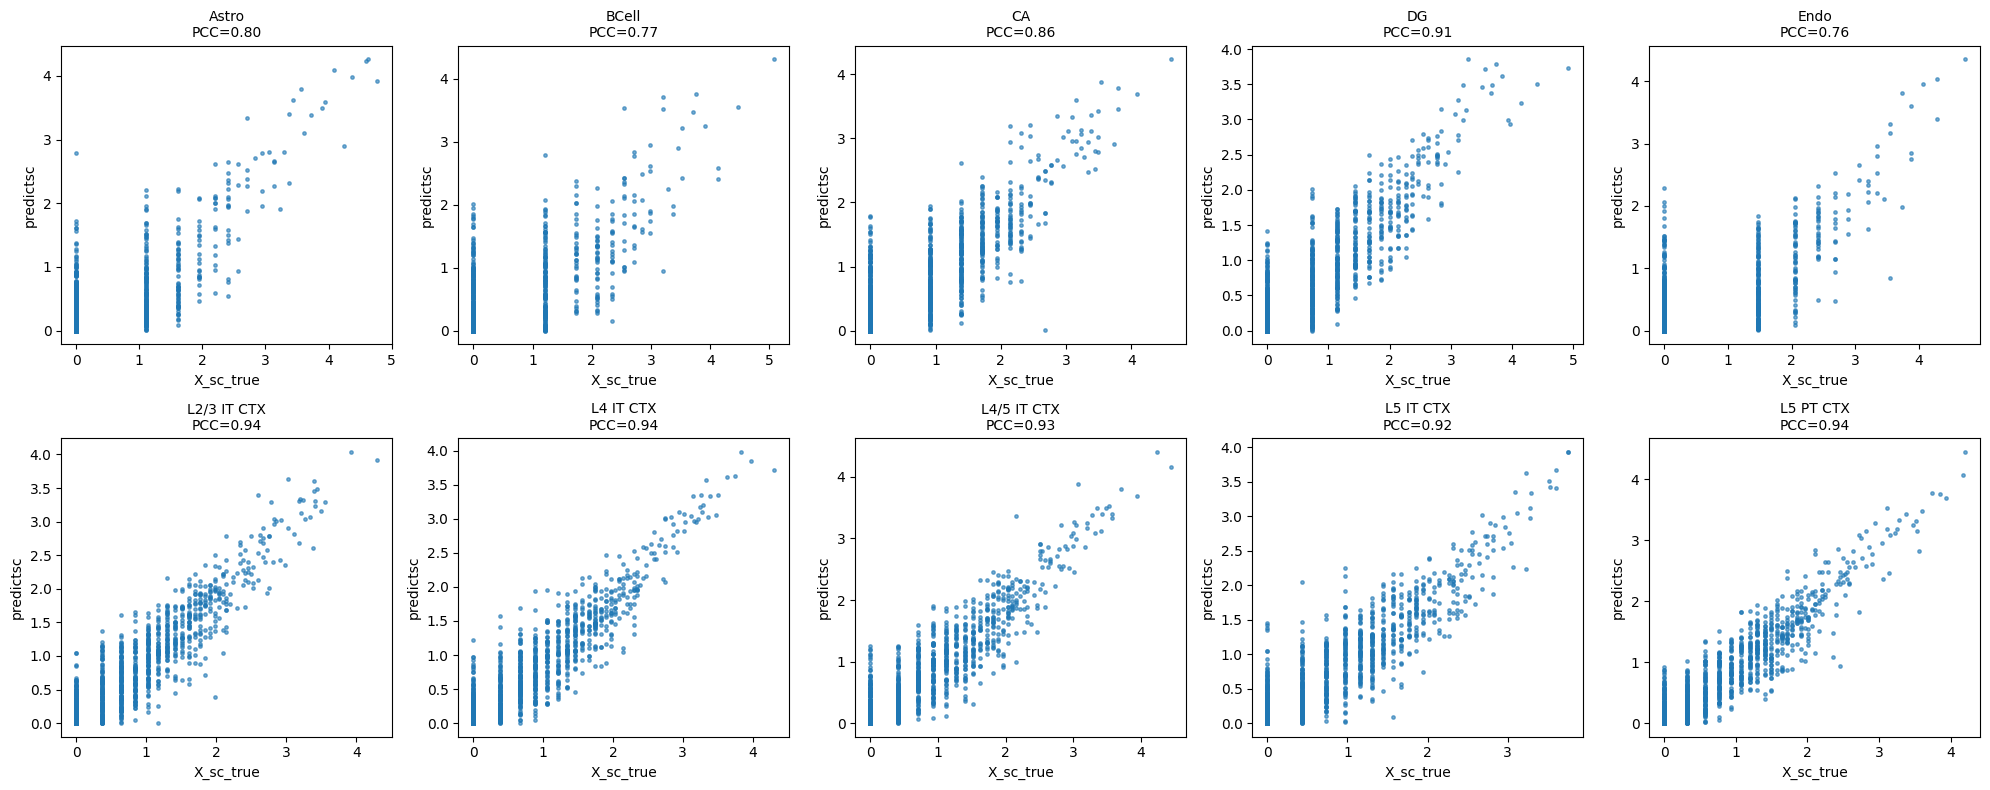

In [24]:
result_ours=evaluate_predictions_numpy(
    predictsc,              # (n_sc_cells, n_genes) or embedding
    scembeding,
    np.log(1+adata_sc.X.toarray()),              # same shape as predictsc (optional, can be None)
    predictst=None,         # (n_spots, n_genes)
    X_st_true=np.log(1+adata_st.X.toarray()),         # (n_spots, n_genes)
    predictA=None,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels,  # list[str], length = n_sc_cells
    A_gt_deconv=A_gt_deconv,       # (n_spots, n_types)
    cell_types_gt_order=cell_types_gt_order
)

In [25]:
result_ours

({'predictsc_row_pcc': 0.8631472627816124,
  'predictsc_col_pcc': 0.7219917304616558,
  'silhouette_index': 0.6518657446452938},
 None)

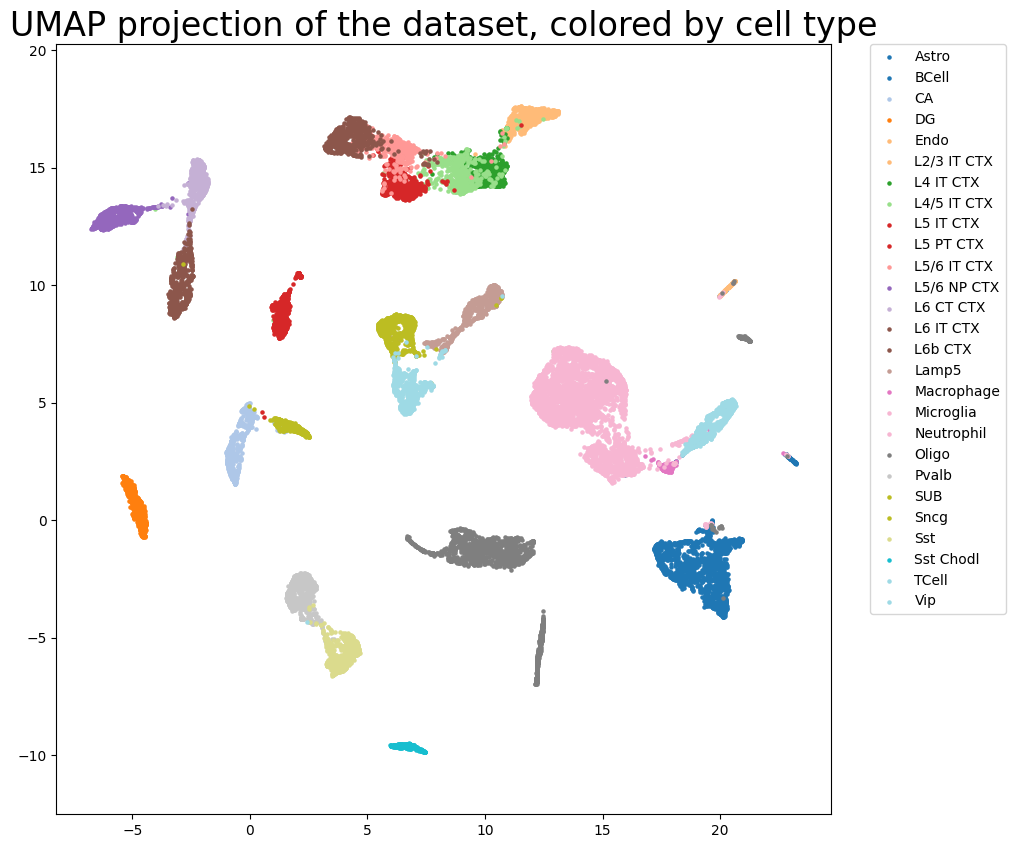

In [26]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# 假设 scembedding 是你的单细胞嵌入数据，形状为 (n_cells, n_features)
# cell_type_labels 是一个包含每个细胞类型的标签列表或数组，长度为 n_cells
# 示例数据
# scembedding = ...  # 你的单细胞嵌入数据
metadata = adata_sc.obs.copy()
cell_type_labels =metadata['cell_type'].values
reducer = umap.UMAP()
embedding = reducer.fit_transform(scembeding)
# 获取所有独特的细胞类型用于配色
unique_cell_types = np.unique(cell_type_labels)
# 为每种细胞类型生成颜色
colors = plt.cm.get_cmap('tab20', len(unique_cell_types))
plt.figure(figsize=(10, 10))
# 绘制每个细胞类型
for i, cell_type in enumerate(unique_cell_types):
    mask = cell_type_labels == cell_type
    plt.scatter(embedding[mask, 0], embedding[mask, 1], c=[colors(i)], label=cell_type, s=5)

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the dataset, colored by cell type', fontsize=24)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [27]:
result0 = pd.DataFrame(embedding,columns=['UMAP1','UMAP2'])
result0['cell_type']=cell_type_labels
result0.to_csv('jiyuanyang_tangrammarker_umap_embedding-tangram.csv',index=False)

## fix the encoder result and optimize A

In [35]:
##### by zzzz
predictsc = np.load('fix_enc_pca1_top5000_kl_soft_harm_fval-tangram_jiyuanyang.npy')
scembeding = np.load('fix_enc_pca1_top5000_kl_soft_harm_z_cell-tangram_jiyuanyang.npy')
pcaguide=pd.read_csv('harmony_embedding.txt', sep='\t', index_col=0)


sc_data_path = "/home/qyyuan/project/ST_CP/JE/method/data/scRNA_subsampled_20k.h5ad"
st_data_path = "/home/qyyuan/project/ST_CP/JE/compare/groundtruth/NM_yangjy_X/data/Visium_FAD.h5ad"
count_file_path='/home/qyyuan/project/ST_CP/JE/method/stardist/count_spot/spot_loc_with_counts_r_f.csv'
checkpoint_path = 'SpatialVG_improved_NMF/models/fix_enc_pca1_top5000_kl_soft_harm-best_result0.5-withmarker2.pth'
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
common_genes=checkpoint['common_genes']

Count_cell=pd.read_csv(count_file_path)
num_cell=Count_cell['n_cells'].values
num_cell = torch.tensor(num_cell, device='cuda:4')
import os
import torch
import numpy as np66

print("=" * 60)
print("Starting improved model training")
print("=" * 60)
# Train model
model, common_genes, losses = train_vae_poisson_model(
    sc_path=sc_data_path,
    st_path=st_data_path,
    num_cell=num_cell,
    output_dir='SpatialVG_improved_NMF', common_genes=common_genes,
    embedding_dim=32, 
    lr=0.05, 
    epochs=500, 
    lambda_reg=1,lambda_l2=0.01,lambda_l4=0,lambda_l5=0.0000000,lambda_ot=0, lambda_M=0.1,lambda_M1=1,lambda_r=0.0000,lambda_kl=0.000,lambda_pca=0,lambda_f=0.1,lambda_row_sum=100,
    n_top_genes=5000 ,
    z_pca=None, predictA=True, f_vals=torch.tensor(predictsc, device='cuda:4'),
    z_cell=torch.tensor(scembeding, device='cuda:4'),
    fix_genes=True
)
# Save results
os.makedirs('SpatialVG_improved_NMF/models', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'common_genes': common_genes,
    'training_losses': losses,
}, 'SpatialVG_improved_NMF/models/fix_enc_pca1_top5000_kl_soft_harm_getA2-jiyuany-tangrammarker.pth')
print("Training completed and model saved.")

Starting improved model training
the number of common gene are 1586
Epoch   0: Total=0.81, LM=0.71,LM1=0.71, l_f=0.21, row_sum_loss=0.55,l3=0.00
Epoch  20: Total=0.78, LM=0.69,LM1=0.69, l_f=0.13, row_sum_loss=0.48,l3=0.00
Epoch  40: Total=0.77, LM=0.69,LM1=0.69, l_f=0.06, row_sum_loss=0.48,l3=0.00
Epoch  60: Total=0.76, LM=0.68,LM1=0.68, l_f=0.03, row_sum_loss=0.48,l3=0.00
Epoch  80: Total=0.75, LM=0.68,LM1=0.68, l_f=0.02, row_sum_loss=0.48,l3=0.00
Epoch 100: Total=0.75, LM=0.68,LM1=0.68, l_f=0.02, row_sum_loss=0.48,l3=0.00
Epoch 120: Total=0.75, LM=0.67,LM1=0.68, l_f=0.01, row_sum_loss=0.48,l3=0.00
Epoch 140: Total=0.75, LM=0.67,LM1=0.67, l_f=0.01, row_sum_loss=0.48,l3=0.00
Epoch 160: Total=0.75, LM=0.67,LM1=0.67, l_f=0.01, row_sum_loss=0.47,l3=0.00
Epoch 180: Total=0.75, LM=0.67,LM1=0.67, l_f=0.01, row_sum_loss=0.47,l3=0.00
Epoch 200: Total=0.75, LM=0.67,LM1=0.67, l_f=0.01, row_sum_loss=0.47,l3=0.00
Epoch 220: Total=0.75, LM=0.67,LM1=0.67, l_f=0.01, row_sum_loss=0.47,l3=0.00
Epoch 24

In [36]:
A_gt_deconv=pd.read_csv('/home/qyyuan/project/ST_CP/JE/compare/groundtruth/NM_yangjy_X/data/S3_GT.txt',sep='\t',header=0,index_col=0)
metadata = adata_sc.obs.copy()
cell_type_labels =metadata['cell_type'].values

In [37]:
model.eval()
device = next(model.parameters()).device
import torch
X_sc_tensor = X_sc.to(device).float()
with torch.no_grad():
    sigmoid_f = torch.sigmoid(model.f).squeeze()
    A_hat = model.compute_softmax_A()
    #A_hat = A_hat  * sigmoid_f 
A_hat_np = A_hat.cpu().numpy()
A_hat_np=pd.DataFrame(A_hat_np,index=adata_st.obs_names,columns=adata_sc.obs_names)
A_hat_np=A_hat_np.loc[A_gt_deconv.index,:]
cell_types_gt_order=A_gt_deconv.columns.tolist()


In [38]:
result_ours=evaluate_predictions_numpy(
    None,              # (n_sc_cells, n_genes) or embedding
    None,
    np.log(1+adata_sc.X.toarray()),              # same shape as predictsc (optional, can be None)
    predictst=None,         # (n_spots, n_genes)
    X_st_true=np.log(1+adata_st.X.toarray()),         # (n_spots, n_genes)
    predictA=A_hat_np,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels,  # list[str], length = n_sc_cells
    A_gt_deconv=A_gt_deconv,       # (n_spots, n_types)
    cell_types_gt_order=cell_types_gt_order
)

✅ Evaluation complete.


In [39]:
result_ours

({'deconv_mean_pcc': 0.49060371056724456,
  'deconv_mean_mae': 0.04609284899078951,
  'deconv_mean_rmse': 0.09717489451791847,
  'PCC_all': [0.71059532079343,
   0.5374563540105326,
   0.6351004706937544,
   0.360353328623788,
   0.5135313116332406,
   0.5783506957703416,
   0.6216529436590565,
   0.3580700362410751,
   0.1729968121808001,
   0.4732607610108765,
   0.07035608486078984,
   0.5665634125821503,
   0.48125050850857853,
   0.5178521316839357,
   0.7114274126602891,
   0.8192361984844019,
   0.2833578501562001,
   0.35739683172705217,
   0.6053011653411151,
   0.27117377567714096,
   0.6242470292348462,
   0.7474640472171152,
   0.4260167613325802,
   0.7345075172425575,
   0.6084828434863845,
   0.4044192777024923,
   0.7974535439637376,
   0.0910009278886759,
   0.009632548816304768,
   0.645121047353951,
   0.4090363419491468,
   0.06695177084477923,
   0.6764213589253123,
   0.34771451383517127,
   0.5320558739560196,
   0.36509414125661405,
   0.7050797426084929,
   0.3

In [40]:
import numpy as np

def get_entropy_uniformity(matrix):
    # 防止 log(0) 报错，加上极小值
    epsilon = 1e-12
    matrix = np.clip(matrix, epsilon, 1)
    
    N = matrix.shape[0] # 行数
    # 计算每列的熵
    entropy = -np.sum(matrix * np.log(matrix), axis=0)
    # 归一化 (除以最大熵 log(N))
    max_entropy = np.log(N)
    uniformity_score = entropy / max_entropy
    
    return uniformity_score

In [70]:
#A_hat_np_n=A_hat_np/A_hat_np.mean(axis=0)
A_hat_np=A_hat_np/A_hat_np.sum(axis=0)
AA=get_entropy_uniformity(A_hat_np)
index0=np.where(AA<0.88)[0]
A_hat_np1 = A_hat_np.iloc[:,index0]


In [71]:
len(index0)

16247

In [72]:
    result_ours,A_dec_pred=evaluate_predictions_numpy(
    None,              # (n_sc_cells, n_genes) or embedding
    None,
    np.log(1+adata_sc.X.toarray()),              # same shape as predictsc (optional, can be None)
    predictst=None,         # (n_spots, n_genes)
    X_st_true=np.log(1+adata_st.X.toarray()),         # (n_spots, n_genes)
    predictA=A_hat_np1,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels[index0],  # list[str], length = n_sc_cells
    A_gt_deconv=A_gt_deconv,       # (n_spots, n_types)
    cell_types_gt_order=cell_types_gt_order
    )

✅ Evaluation complete.


In [46]:
np.save('A_dec_pred-best_by_2026-04-29_TANGRAM_JIYUANYANG.npy', A_dec_pred)

In [73]:
result_ours

{'deconv_mean_pcc': 0.5260915225111898,
 'deconv_mean_mae': 0.045061111111271306,
 'deconv_mean_rmse': 0.09522162773275612,
 'PCC_all': [0.7846614583166788,
  0.574493075169937,
  0.6783461898347052,
  0.3951306169929445,
  0.6030579012622614,
  0.5641587128750102,
  0.6836117451179754,
  0.3772812520117436,
  0.20239633242074462,
  0.49309099362185843,
  0.0735998452832223,
  0.666424027975541,
  0.5445604754172497,
  0.5266991028432412,
  0.7437120219827712,
  0.818298740601644,
  0.2758897147643631,
  0.3699065300133157,
  0.7021264515558878,
  0.259774011480078,
  0.6449990952027841,
  0.8250810197121844,
  0.459826147084779,
  0.7683356502380247,
  0.777425068360385,
  0.40772695464557007,
  0.8015256749675894,
  0.09195733290101535,
  0.002119034675046428,
  0.6770051062545627,
  0.45710117406235945,
  0.08139531158350241,
  0.7881911677709441,
  0.3632933858254012,
  0.5757058410140323,
  0.3533478086615122,
  0.7490237401108966,
  0.3444173020016438,
  0.5788411279371916,
  0.7

In [74]:
A_dec_pred1=A_dec_pred.copy()
A_dec_pred1=A_dec_pred1.T/A_dec_pred1.sum(axis=1)
A_dec_pred1=A_dec_pred1.T
AA=get_entropy_uniformity(A_dec_pred1.T)

In [48]:
index1=np.where(AA<0.90)[0]
len(index1)

3097

temp

In [49]:
            pcc_list = []
            for i in range(A_gt_deconv.iloc[index1,:].shape[0]):
                gt_i = A_gt_deconv.iloc[index1,:].values[i]
                pred_i = A_dec_pred1[index1,:][i]
                if np.std(gt_i) < 1e-8 or np.std(pred_i) < 1e-8:
                    r = 0.0
                    print(1)
                else:
                    r, _ = pearsonr(gt_i, pred_i)
                    r = float(r) if np.isfinite(r) else 0.0
                pcc_list.append(r)
            float(np.mean(pcc_list))

0.5312512964484557

In [75]:
import torch
import numpy as np

def generate_optimized_A_softmax_normalized(A0, adj_matrix, lambda_reg=10.0, lr=0.05, epochs=1000):
    """
    使用归一化拉普拉斯矩阵的版本
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. 数据准备
    A0_tensor = torch.tensor(A0, dtype=torch.float32).to(device)
    W = torch.tensor(adj_matrix, dtype=torch.float32).to(device)
    
    # 2. 构建【归一化】拉普拉斯矩阵 (Symmetric Normalized Laplacian)
    # L_sym = I - D^(-1/2) * W * D^(-1/2)
    
    # 计算度矩阵 D (每一行的和)
    D_vec = torch.sum(W, dim=1)
    
    # 计算 D^(-1/2)
    # 加上 eps 防止除以 0 (如果有孤立点)
    eps = 1e-18
    D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D_vec + eps))
    
    # 计算 L_sym
    # I 是单位矩阵
    I = torch.eye(W.shape[0]).to(device)
    L_sym = I - torch.mm(torch.mm(D_inv_sqrt, W), D_inv_sqrt)
    
    # 3. 初始化 S (Logits)
    eps_log = 1e-18
    S_init = torch.log(A0_tensor + eps_log)
    S = torch.nn.Parameter(S_init + torch.randn_like(S_init) * 0.01)
    
    optimizer = torch.optim.Adam([S], lr=lr)
    
    print(f"开始优化 (使用归一化拉普拉斯, Device: {device})...")
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # --- 核心：通过 Softmax 得到 A ---
        A = torch.softmax(S, dim=1)
        
        # --- 目标 1: 余弦相似度 ---
        norm_A = torch.norm(A, dim=1, keepdim=True)
        norm_A0 = torch.norm(A0_tensor, dim=1, keepdim=True)
        norm_A = torch.clamp(norm_A, min=1e-8)
        norm_A0 = torch.clamp(norm_A0, min=1e-8)
        
        dot_product = torch.sum(A * A0_tensor, dim=1, keepdim=True)
        cos_sim = dot_product / (norm_A * norm_A0)
        loss_sim = torch.mean(1 - cos_sim)
        
        # --- 目标 2: 图平滑性 (使用 L_sym) ---
        # Tr(A^T * L_sym * A)
        # 注意：这里直接用矩阵乘法链式计算
        loss_smooth = torch.trace(torch.mm(torch.mm(A.t(), L_sym), A))
        
        # --- 总损失 ---
        loss = loss_sim + lambda_reg * loss_smooth
        
        loss.backward()
        optimizer.step()
        
        # 监控
        if (epoch + 1) % 200 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, "
                  f"Sim: {loss_sim.item():.4f}, Smooth: {loss_smooth.item():.4f}")
            
    A_final = torch.softmax(S, dim=1)
    return A_final.detach().cpu().numpy()

# ==========================================
# 使用示例
# ==========================================
# 注意：lambda_reg 可能需要调大，因为归一化后 Smooth Loss 数值会变小
# A_result = generate_optimized_A_softmax_normalized(A0_prob, adj_data, lambda_reg=50.0)

In [51]:
count_file_path='/home/qyyuan/project/ST_CP/JE/method/stardist/count_spot/spot_loc_with_counts_r_f.csv'
Count_cell=pd.read_csv(count_file_path,index_col=0)
Count_cell=Count_cell.loc[A_gt_deconv.index,:]
Count_cell[['imagerow','imagecol']]

,imagerow,imagecol
AAACACCAATAACTGC-1,7120,2698
AAACAGAGCGACTCCT-1,2706,6900
AAACAGCTTTCAGAAG-1,5557,2131
AAACAGGGTCTATATT-1,5947,2357
AAACCGGGTAGGTACC-1,5456,3199
...,...,...
TTGTTGTGTGTCAAGA-1,4372,5950
TTGTTTCACATCCAGG-1,7018,3990
TTGTTTCATTAGTCTA-1,7216,3316
TTGTTTCCATACAACT-1,5749,3143


In [76]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# 1. 模拟数据：假设 coords 是你的 (3000, 2) 坐标矩阵
# np.random.seed(42)
# coords = np.random.rand(3000, 2) * 100  # 替换为你真实的 x, y 数据
coords=Count_cell[['imagerow','imagecol']].values
# 2. 构建 KNN 模型
# n_neighbors=10 表示找最近的10个点 (包含自身)
# metric='euclidean' 表示使用欧几里得距离
knn = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn.fit(coords)
# 3. 获取邻接关系
# kneighbors 返回两个矩阵：(距离, 索引)
distances, indices = knn.kneighbors(coords)

# 4. 生成邻接矩阵 (Adjacency Matrix)
# 初始化一个全 0 矩阵
adj_matrix = np.zeros((coords.shape[0], coords.shape[0]))

# 填充矩阵
# 对于每一行 i，将 indices[i] 对应的位置设为 1 (或者设为具体的距离值)
for i in range(coords.shape[0]):
    adj_matrix[i, indices[i]] = 1 
    # 如果你想用距离作为权重，可以使用: adj_matrix[i, indices[i]] = 1 / (distances[i] + 1e-5)

# 5. (可选) 对称化
# 如果 A 是 B 的邻居，通常也让 B 是 A 的邻居 (无向图)
adj_matrix = np.maximum(adj_matrix, adj_matrix.T)

print("邻接矩阵形状:", adj_matrix.shape)
print("非零元素数量:", np.count_nonzero(adj_matrix))

邻接矩阵形状: (3243, 3243)
非零元素数量: 17667


In [83]:
# ==========================================
# 模拟数据与运行示例
# ==========================================

A0_data = A_dec_pred1.copy()

# 2. 模拟 距离矩阵/KNN网络 (3000 x 3000)
# 这里为了演示，随机生成一个稀疏的邻接矩阵
# 实际使用时，请用你的 KNN 结果替换这里

adj_data = adj_matrix.copy()

# 3. 运行优化
# lambda_reg 越大，相邻的行使向量越相似；越小，越贴近 A0
A_optimized = generate_optimized_A_softmax_normalized(A0_data, adj_data, lambda_reg=0.01, epochs=5000)

print("优化完成，A 的形状:", A_optimized.shape)

开始优化 (使用归一化拉普拉斯, Device: cuda)...
Epoch 200, Loss: 0.0370, Sim: 0.0244, Smooth: 1.2612
Epoch 400, Loss: 0.0370, Sim: 0.0244, Smooth: 1.2612
Epoch 600, Loss: 0.0370, Sim: 0.0244, Smooth: 1.2612
Epoch 800, Loss: 0.0370, Sim: 0.0244, Smooth: 1.2612
Epoch 1000, Loss: 0.0370, Sim: 0.0244, Smooth: 1.2612
Epoch 1200, Loss: 0.0370, Sim: 0.0244, Smooth: 1.2612
Epoch 1400, Loss: 0.0370, Sim: 0.0244, Smooth: 1.2612
Epoch 1600, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2613
Epoch 1800, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2614
Epoch 2000, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2614
Epoch 2200, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2613
Epoch 2400, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2614
Epoch 2600, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2614
Epoch 2800, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2614
Epoch 3000, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2614
Epoch 3200, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2615
Epoch 3400, Loss: 0.0371, Sim: 0.0244, Smooth: 1.2618
Epoch 3600, Loss: 0.0371, Sim: 0.0244, Smooth: 1.261

In [84]:
            pcc_list = []
            for i in range(A_gt_deconv.iloc[:,:].shape[0]):
                gt_i = A_gt_deconv.iloc[:,:].values[i]
                pred_i = A_optimized[:,:][i]
                if np.std(gt_i) < 1e-8 or np.std(pred_i) < 1e-8:
                    r = 0.0
                    print(1)
                else:
                    r, _ = pearsonr(gt_i, pred_i)
                    r = float(r) if np.isfinite(r) else 0.0
                pcc_list.append(r)
            float(np.mean(pcc_list))

0.5538304400162274

In [85]:
A_optimized1=A_optimized.copy()
A_optimized1[A_optimized1<0.001]=0

In [86]:
            pcc_list = []
            for i in range(A_gt_deconv.iloc[:,:].shape[0]):
                gt_i = A_gt_deconv.iloc[:,:].values[i]
                pred_i = A_optimized1[:,:][i]
                if np.std(gt_i) < 1e-8 or np.std(pred_i) < 1e-8:
                    r = 0.0
                    print(1)
                else:
                    r, _ = pearsonr(gt_i, pred_i)
                    r = float(r) if np.isfinite(r) else 0.0
                pcc_list.append(r)
            float(np.mean(pcc_list))

0.5538204217448429

In [239]:
np.save( 'pcc_list_0.5-best_by_2026-04-07-version2.npy',np.array(pcc_list))

In [243]:
import numpy as np
#pcc_list = np.load('pcc_list_0.5-best_by_2026-04-07-version2.npy')
import pandas as pd
data0 = pd.DataFrame({'pcc': pcc_list})

In [244]:
data0.to_csv('/home/qyyuan/project/ST_CP/JE/method/result/decon/pcc_list_0.5-best_by_2026-04-07-version2.csv', index=False)

In [ ]:
pd.DataFrame(result_ours['PCC_all'],index=A_gt_deconv.index).to_csv('/home/qyyuan/project/ST_CP/JE/method/result/decon/pcc_list_0.5-best_by_2026-04-07-version2.csv')

(2753, 1)

## st embeding

In [14]:
import numpy as np
scembeding=np.load("/home/qyyuan/project/ST_CP/JE/method/fix_enc_pca1_top5000_kl_soft_harm_z_cell.npy")

In [15]:
sc_path = "/home/qyyuan/project/ST_CP/JE/method/data/scRNA_subsampled_20k.h5ad"
st_path = "/home/qyyuan/project/ST_CP/JE/compare/groundtruth/NM_yangjy_X/data/Visium_FAD.h5ad"
# 1. 定义设备
n_top_genes=5000
device = torch.device('cuda:4' if torch.cuda.is_available() else 'cpu')
checkpoint_path = 'SpatialVG_improved_NMF/models/fix_enc_pca1_top5000_kl_soft_harm-best_result0.5-withmarker2.pth'
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
common_genes=checkpoint['common_genes']
X_sc, X_st, Y, adata_sc, adata_ST, common_genes = load_and_align_data(sc_path, st_path, n_top_genes,common_genes=common_genes,fix_genes=True)
X_sc = np.log(X_sc + 1)
X_st = np.log(X_st + 1)

n_sc_cells=X_sc.shape[0]
n_st_spots=X_st.shape[0]
n_genes=len(common_genes)

the number of common gene are 1586


In [16]:
    model = VAEImprovedSpatialModel(
        n_sc_cells=X_sc.shape[0],
        n_st_spots=X_st.shape[0],
        n_genes=X_sc.shape[1],
        embedding_dim=32)

In [17]:
checkpoint_path = 'SpatialVG_improved_NMF/models/fix_enc_pca1_top5000_kl_soft_harm_getA2.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [19]:
adata_st=sc.read(st_path)

In [26]:
model.eval()
device = next(model.parameters()).device
import torch
X_sc_tensor = X_sc.to(device).float()
with torch.no_grad():
    sigmoid_f = torch.sigmoid(model.f).squeeze()
    A_hat = model.compute_softmax_A()
    A_hat1 = A_hat  * sigmoid_f 
A_hat_np = A_hat1.cpu().numpy()
stembeding = A_hat_np @ scembeding
#np.save('result/jiyuanyang_marker_stembeding_filter.npy', stembeding)
#np.save('result/jiyuanyang_marker_scembeding_filter.npy', scembeding)

In [27]:
metadata = adata_sc.obs.copy()
cell_type_labels =metadata['cell_type'].values

In [28]:
A_gt_deconv=pd.read_csv('/home/qyyuan/project/ST_CP/JE/compare/groundtruth/NM_yangjy_X/data/S3_GT.txt',sep='\t',header=0,index_col=0)
cell_types_gt_order=A_gt_deconv.columns
A_hat_np=pd.DataFrame(A_hat_np,columns=adata_sc.obs_names,index=adata_ST.obs_names)

A_hat_np=A_hat_np.loc[A_gt_deconv.index,:]

In [30]:
result_ours,A_dec_pred=evaluate_predictions_numpy(
    None,              # (n_sc_cells, n_genes) or embedding
    scembeding,
    np.log(1+adata_sc.X.toarray()),              # same shape as predictsc (optional, can be None)
    predictst=None,         # (n_spots, n_genes)
    X_st_true=np.log(1+adata_ST.X.toarray()),         # (n_spots, n_genes)
    predictA=A_hat_np,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels,  # list[str], length = n_sc_cells
    A_gt_deconv=A_gt_deconv,       # (n_spots, n_types)
    cell_types_gt_order=cell_types_gt_order
)

✅ Evaluation complete.
